# Human mobility - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.

> Each prompt produces roughly the matching cell in the **Lane B** notebook.


## About this data source

**US Census LODES (ground mobility).** Every year the Census links *where people live* to
*where they work*, from employment records. Free, nationwide, down to the neighbourhood.
Think of it as: *"how many people sleep in county A and work in county B?"* That commuting
shed is the ground truth for which neighbours you exchange people with daily.

- **Explore it in a browser:** <https://onthemap.ces.census.gov/> (click a county, watch the
  arrows showing where its workers come from)
- Raw files: <https://lehd.ces.census.gov/data/>

**OpenFlights (air mobility).** A volunteer-built, open database of the world's airports and
airline routes. Not passenger counts, but the *wiring diagram* of global air travel, which is
how a distant outbreak becomes a local case.

- **Explore it in a browser:** <https://openflights.org/> (search an airport, see every route
  drawn on a world map)

> The gold standard here is GLEAM (Vespignani's lab), which uses licensed OAG/IATA and
> national commuting data. These two are the free stand-ins.


## Step 1: ground mobility

> *Using US Census LODES origin-destination data (LODES8, Georgia, JT00, 2021), for*
> *Fulton County GA (FIPS 13121), rank the counties that send the most commuters in.*
> *County = first 5 digits of the block geocode; sum the S000 column. Return the top 10*
> *as a tidy table with county names (use the Census national_county2020 lookup), and*
> *plot them. Note the file is ~22 MB, so cache the aggregate.*

**Your check:** do the top feeders look like the real commuter shed for that county?


Using cached LODES aggregate: ../data/lodes_fulton_inflow_top_counties.csv


,home_county_fips,home_county,commuters_to_fulton,share_pct
0,13121,"Fulton County, GA",234257,27.39
1,13089,"DeKalb County, GA",119060,13.92
2,13067,"Cobb County, GA",108147,12.65
3,13135,"Gwinnett County, GA",86184,10.08
4,13117,"Forsyth County, GA",37252,4.36
5,13063,"Clayton County, GA",36714,4.29
6,13057,"Cherokee County, GA",30456,3.56
7,13151,"Henry County, GA",24290,2.84
8,13097,"Douglas County, GA",17160,2.01
9,13223,"Paulding County, GA",15033,1.76


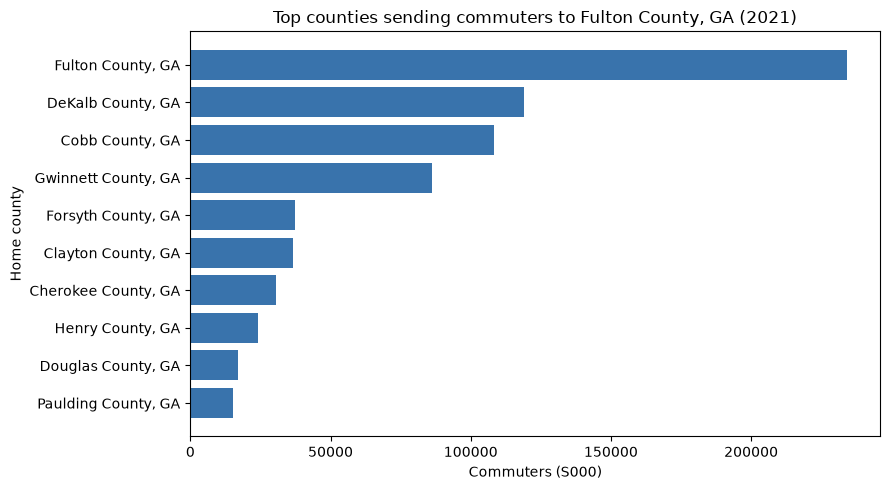

In [1]:
from pathlib import Path
import gzip
import io

import matplotlib.pyplot as plt
import pandas as pd
import requests

TARGET_FIPS = '13121'  # Fulton County, GA
LODES_URL = ('https://lehd.ces.census.gov/data/lodes/LODES8/ga/od/'
             'ga_od_main_JT00_2021.csv.gz')
COUNTY_URL = ('https://www2.census.gov/geo/docs/reference/codes2020/'
              'national_county2020.txt')
cache_candidates = [
    Path('../data/lodes_fulton_inflow_top_counties.csv'),
    Path('data/lodes_fulton_inflow_top_counties.csv'),
]
cache_file = next((path for path in cache_candidates if path.exists()),
                  cache_candidates[0])

if cache_file.exists():
    print(f'Using cached LODES aggregate: {cache_file}')
    county_inflow = pd.read_csv(cache_file, dtype={'home_county_fips': 'string'})
else:
    # Download once, then retain only the small county-level aggregate.
    response = requests.get(LODES_URL, timeout=300)
    response.raise_for_status()
    inflow = {}
    with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as zipped:
        for chunk in pd.read_csv(
            zipped, usecols=['h_geocode', 'w_geocode', 'S000'],
            dtype={'h_geocode': 'string', 'w_geocode': 'string', 'S000': 'int64'},
            chunksize=500_000,
        ):
            to_fulton = chunk[chunk['w_geocode'].str[:5].eq(TARGET_FIPS)].copy()
            to_fulton['home_county_fips'] = to_fulton['h_geocode'].str[:5]
            counts = to_fulton.groupby('home_county_fips')['S000'].sum()
            for county, commuters in counts.items():
                inflow[county] = inflow.get(county, 0) + commuters

    counties = pd.read_csv(COUNTY_URL, sep='|', dtype=str)
    counties['home_county_fips'] = counties['STATEFP'] + counties['COUNTYFP']
    counties['home_county'] = counties['COUNTYNAME'] + ', ' + counties['STATE']
    county_names = counties.set_index('home_county_fips')['home_county']
    county_inflow = (
        pd.Series(inflow, name='commuters_to_fulton')
        .rename_axis('home_county_fips').reset_index()
        .assign(home_county=lambda x: x['home_county_fips'].map(county_names))
        .sort_values('commuters_to_fulton', ascending=False)
        .reset_index(drop=True)
    )
    total = county_inflow['commuters_to_fulton'].sum()
    county_inflow['share_pct'] = 100 * county_inflow['commuters_to_fulton'] / total
    cache_file.parent.mkdir(parents=True, exist_ok=True)
    county_inflow.to_csv(cache_file, index=False)
    print(f'Cached LODES aggregate: {cache_file}')

top10 = county_inflow.nlargest(10, 'commuters_to_fulton').copy()
top10['share_pct'] = top10['share_pct'].round(2)
display(top10)

plot_data = top10.sort_values('commuters_to_fulton')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data['home_county'], plot_data['commuters_to_fulton'], color='#3973ac')
ax.set(title='Top counties sending commuters to Fulton County, GA (2021)',
       xlabel='Commuters (S000)', ylabel='Home county')
fig.tight_layout()
plt.show()


## Step 2: air mobility

> *I want the countries that connect to Atlanta (ATL) as a proxy for air-importation*
> *risk. Note the OpenSky API now needs a free account and OAuth2 (anonymous gets 403),*
> *so use the free OpenFlights routes.dat + airports.dat instead: count inbound routes*
> *to ATL by origin airport, map to country, and rank the top countries. Plot the top 10*
> *excluding domestic.*

**Your check:** routes measure *structure*, not passenger volume. What would you need to
turn this into real importation risk?


Using cached OpenFlights aggregate: ../data/openflights_atl_inbound.csv


,origin_country,n_routes
0,Mexico,44
1,Germany,15
2,United Kingdom,12
3,Canada,9
4,Puerto Rico,8
5,Bahamas,6
6,Jamaica,5
7,Italy,5
8,Brazil,4
9,France,4


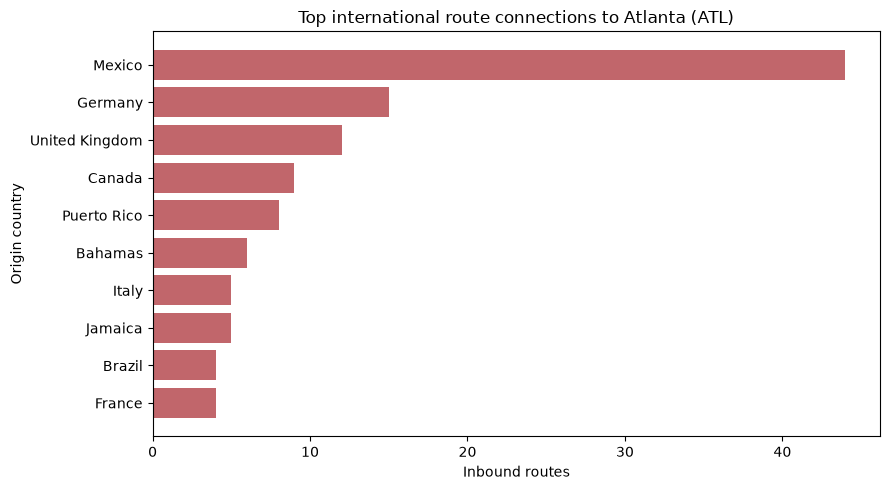

In [2]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

AIRPORT = 'ATL'
AIRPORTS_URL = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat'
ROUTES_URL = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat'
cache_candidates = [
    Path('../data/openflights_atl_inbound.csv'),
    Path('data/openflights_atl_inbound.csv'),
]
cache_file = next((path for path in cache_candidates if path.exists()),
                  cache_candidates[0])

if cache_file.exists():
    print(f'Using cached OpenFlights aggregate: {cache_file}')
    inbound = pd.read_csv(cache_file)
else:
    airports_response = requests.get(AIRPORTS_URL, timeout=60)
    routes_response = requests.get(ROUTES_URL, timeout=60)
    airports_response.raise_for_status()
    routes_response.raise_for_status()

    # OpenFlights columns: city=2, country=3, IATA=4; route source=2, destination=4.
    airports = pd.read_csv(StringIO(airports_response.text), header=None,
                           usecols=[2, 3, 4], names=['origin_city', 'origin_country',
                                                        'origin_airport'],
                           keep_default_na=False)
    routes = pd.read_csv(StringIO(routes_response.text), header=None, usecols=[2, 4],
                         names=['origin_airport', 'destination_airport'],
                         keep_default_na=False)
    route_counts = (
        routes.loc[routes['destination_airport'].eq(AIRPORT)]
        .groupby('origin_airport').size().rename('n_routes').reset_index()
    )
    inbound = (
        route_counts.merge(airports, on='origin_airport', how='inner')
        .sort_values('n_routes', ascending=False).reset_index(drop=True)
    )
    cache_file.parent.mkdir(parents=True, exist_ok=True)
    inbound.to_csv(cache_file, index=False)
    print(f'Cached OpenFlights aggregate: {cache_file}')

top_countries = (
    inbound.loc[inbound['origin_country'].ne('United States')]
    .groupby('origin_country', as_index=False)['n_routes'].sum()
    .sort_values('n_routes', ascending=False).head(10)
    .reset_index(drop=True)
)
display(top_countries)

plot_data = top_countries.sort_values('n_routes')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data['origin_country'], plot_data['n_routes'], color='#c1666b')
ax.set(title='Top international route connections to Atlanta (ATL)',
       xlabel='Inbound routes', ylabel='Origin country')
fig.tight_layout()
plt.show()


## Step 3: sanity-check and save

> *Report row counts for both tables, confirm the commuter shares sum sensibly, and save*
> *both to tidy CSVs.*


In [3]:
print('county inflow rows:', len(county_inflow))
print('inbound-airport rows:', len(inbound))
print(f'commuter share represented by the available county table: '
      f"{county_inflow['share_pct'].sum():.1f}%")
print(f'commuter share represented by the top 10: {top10['share_pct'].sum():.1f}%')

top10.to_csv('mobility_ground_top_counties.csv', index=False)
top_countries.to_csv('mobility_air_top_countries.csv', index=False)
print('saved mobility_ground_top_counties.csv and mobility_air_top_countries.csv')


county inflow rows: 15
inbound-airport rows: 216
commuter share represented by the available county table: 88.6%
commuter share represented by the top 10: 82.9%
saved mobility_ground_top_counties.csv and mobility_air_top_countries.csv


## Reflection

- Ground = which neighbours seed you; air = which distant places import risk.
- Both are free proxies for GLEAM's licensed OAG / IATA / commuting data.
- Feeds the ARGONet network idea in the 1:30 session.


# Stretch: Find mobility flows for your location of interest

In [4]:
# Netherlands mobility imports: a reusable, source-normalized schema.
from pathlib import Path

import pandas as pd
import requests

CACHE_DIR = Path('../data/nl_mobility')
REFRESH = False
CBS_COMMUTING = 'https://opendata.cbs.nl/ODataApi/OData/85481NED'
CBS_RAIL = 'https://opendata.cbs.nl/ODataApi/OData/86172ENG'
WORK_REGION = 'GM0363'       # Amsterdam; change after inspecting WerkregioS
COMMUTING_PERIOD = '2023MM12'

locations_file = CACHE_DIR / 'nl_locations.csv'
flows_file = CACHE_DIR / 'nl_mobility_flows.csv'
entry_file = CACHE_DIR / 'nl_entry_point_flows.csv'
metadata_file = CACHE_DIR / 'nl_source_metadata.csv'

if not REFRESH and all(path.exists() for path in [locations_file, flows_file,
                                                  entry_file, metadata_file]):
    locations = pd.read_csv(locations_file)
    mobility_flows = pd.read_csv(flows_file, parse_dates=['period_start', 'period_end'])
    entry_point_flows = pd.read_csv(entry_file, parse_dates=['period_start', 'period_end'])
    source_metadata = pd.read_csv(metadata_file, parse_dates=['retrieved_at'])
    print(f'Using cached Netherlands imports: {CACHE_DIR}')
else:
    # Registry: the points at which a later airport, ferry, or rail-border adapter can land.
    locations = pd.DataFrame([
        ('NL-AMS-SCH', 'Amsterdam Airport Schiphol', 'airport'),
        ('NL-RTM-HVH', 'Hook of Holland', 'ferry_terminal'),
        ('NL-AMS-IJM', 'IJmuiden', 'ferry_terminal'),
        ('NL-ARN', 'Arnhem Centraal', 'rail_border_station'),
        ('NL-VEN', 'Venlo', 'rail_border_station'),
        ('NL-MST', 'Maastricht', 'rail_border_station'),
    ], columns=['location_id', 'name', 'entry_point_type']).assign(
        country_code='NL', is_border_entry_point=True
    )

    def cbs_get(url, **params):
        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        return pd.DataFrame(response.json()['value'])

    # Stable origin-destination commuter network (annual December snapshot).
    commute_raw = cbs_get(
        f'{CBS_COMMUTING}/TypedDataSet',
        **{'$filter': f"WerkregioS eq '{WORK_REGION}' and Perioden eq '{COMMUTING_PERIOD}'"},
    )
    home_regions = cbs_get(f'{CBS_COMMUTING}/WoonregioS')[['Key', 'Title']]
    work_regions = cbs_get(f'{CBS_COMMUTING}/WerkregioS')[['Key', 'Title']]
    home_names = home_regions.set_index('Key')['Title']
    work_names = work_regions.set_index('Key')['Title']
    commute_start = pd.Timestamp(f"{COMMUTING_PERIOD[:4]}-{COMMUTING_PERIOD[-2:]}-01")
    commuting_flows = pd.DataFrame({
        'period_start': commute_start,
        'period_end': commute_start + pd.offsets.MonthEnd(0),
        'source': 'cbs_commuting_85481NED',
        'mode': 'commute',
        'origin_id': commute_raw['WoonregioS'].str.strip(),
        'origin_name': commute_raw['WoonregioS'].map(home_names),
        'destination_id': commute_raw['WerkregioS'].str.strip(),
        'destination_name': commute_raw['WerkregioS'].map(work_names),
        'flow_value': 1_000 * commute_raw['BanenVanWerknemers_1'],
        'flow_unit': 'worker_jobs',
        'is_international': commute_raw['WoonregioS'].str.strip().eq('NL98'),
        'is_entry_flow': False,
        'coverage_note': 'Annual worker-job OD snapshot; not observed border entry.',
    })

    # National rail activity. International records are not directional or station-specific.
    rail_raw = cbs_get(f'{CBS_RAIL}/TypedDataSet')
    rail_types = cbs_get(f'{CBS_RAIL}/PassengerFlows')[['Key', 'Title']]
    rail_names = rail_types.set_index('Key')['Title']
    is_quarter = rail_raw['Periods'].str.contains('KW', na=False)
    rail_start = pd.Series(pd.NaT, index=rail_raw.index, dtype='datetime64[ns]')
    rail_end = rail_start.copy()
    quarter_periods = pd.PeriodIndex(
        rail_raw.loc[is_quarter, 'Periods'].str[:4] + 'Q'
        + rail_raw.loc[is_quarter, 'Periods'].str[-1:], freq='Q'
    )
    rail_start.loc[is_quarter] = quarter_periods.to_timestamp(how='start')
    rail_end.loc[is_quarter] = quarter_periods.to_timestamp(how='end').normalize()
    rail_start.loc[~is_quarter] = pd.to_datetime(rail_raw.loc[~is_quarter, 'Periods'].str[:4] + '-01-01')
    rail_end.loc[~is_quarter] = pd.to_datetime(rail_raw.loc[~is_quarter, 'Periods'].str[:4] + '-12-31')
    rail_flows = pd.DataFrame({
        'period_start': rail_start,
        'period_end': rail_end,
        'source': 'cbs_rail_86172ENG',
        'mode': 'rail',
        'origin_id': 'unknown',
        'origin_name': rail_raw['PassengerFlows'].map(rail_names),
        'destination_id': 'NL',
        'destination_name': 'Netherlands rail network',
        'flow_value': 1_000_000 * rail_raw['Passengers_1'],
        'flow_unit': 'passenger_journeys',
        'is_international': rail_raw['PassengerFlows'].eq('A053220'),
        'is_entry_flow': False,
        'coverage_note': 'National activity only; international journeys are not directional or station-specific.',
    })

    mobility_flows = pd.concat([commuting_flows, rail_flows], ignore_index=True)
    entry_point_flows = pd.DataFrame(columns=[
        'period_start', 'period_end', 'source', 'mode', 'entry_point_id',
        'origin_country', 'origin_region', 'flow_value', 'flow_unit', 'coverage_note',
    ])
    source_metadata = pd.DataFrame([
        ('cbs_commuting_85481NED', CBS_COMMUTING, 'annual', 'municipality OD',
         'Worker jobs, in thousands at source; transformed to counts.'),
        ('cbs_rail_86172ENG', CBS_RAIL, 'quarterly/annual', 'national',
         'International rail journeys are not directional or station-specific.'),
    ], columns=['source', 'source_url', 'temporal_resolution', 'geographic_resolution',
                'coverage_note']).assign(retrieved_at=pd.Timestamp.now(tz='UTC'))

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    locations.to_csv(locations_file, index=False)
    mobility_flows.to_csv(flows_file, index=False)
    entry_point_flows.to_csv(entry_file, index=False)
    source_metadata.to_csv(metadata_file, index=False)
    print(f'Cached Netherlands imports: {CACHE_DIR}')

print('locations:', len(locations), '| mobility flows:', len(mobility_flows),
      '| observed entry flows:', len(entry_point_flows))
display(locations)
display(mobility_flows.head())


Using cached Netherlands imports: ../data/nl_mobility
locations: 6 | mobility flows: 452 | observed entry flows: 0


,location_id,name,entry_point_type,country_code,is_border_entry_point
0,NL-AMS-SCH,Amsterdam Airport Schiphol,airport,NL,True
1,NL-RTM-HVH,Hook of Holland,ferry_terminal,NL,True
2,NL-AMS-IJM,IJmuiden,ferry_terminal,NL,True
3,NL-ARN,Arnhem Centraal,rail_border_station,NL,True
4,NL-VEN,Venlo,rail_border_station,NL,True
5,NL-MST,Maastricht,rail_border_station,NL,True


,period_start,period_end,source,mode,origin_id,origin_name,destination_id,destination_name,flow_value,flow_unit,is_international,is_entry_flow,coverage_note
0,2023-12-01,2023-12-31,cbs_commuting_85481NED,commute,NL00,"Nederland, Buitenland, Niet in te delen",GM0363,Amsterdam,723900.0,worker_jobs,False,False,Annual worker-job OD snapshot; not observed bo...
1,2023-12-01,2023-12-31,cbs_commuting_85481NED,commute,NL01,Nederland,GM0363,Amsterdam,710000.0,worker_jobs,False,False,Annual worker-job OD snapshot; not observed bo...
2,2023-12-01,2023-12-31,cbs_commuting_85481NED,commute,NL99,Nederland; niet in te delen,GM0363,Amsterdam,13900.0,worker_jobs,False,False,Annual worker-job OD snapshot; not observed bo...
3,2023-12-01,2023-12-31,cbs_commuting_85481NED,commute,LD01,Noord-Nederland (LD),GM0363,Amsterdam,9700.0,worker_jobs,False,False,Annual worker-job OD snapshot; not observed bo...
4,2023-12-01,2023-12-31,cbs_commuting_85481NED,commute,LD02,Oost-Nederland (LD),GM0363,Amsterdam,54100.0,worker_jobs,False,False,Annual worker-job OD snapshot; not observed bo...
